In [1]:
from result import Result
import os
import pandas as pd

In [2]:
def mean_accuracy_extractor(results_dict: str):
    files = [f for f in os.listdir(results_dict) if f.endswith(".json")]

    data_rows = {}

    for file in files:
        file_key = os.path.splitext(file)[0]

        result = Result({})
        result.load_json(results_dict + file)
        temp_df = result.tabulate()

        data_rows[file_key] = temp_df.mean()

    final_df = pd.DataFrame.from_dict(data_rows, orient="index")
    final_df.drop("seed", axis=1, inplace=True)
    return final_df

In [3]:
mean_df = mean_accuracy_extractor("results/")
mean_df

Successfully loaded results from results/with_additional_features_ANN_{'loss': 'categorical_crossentropy', 'lr': 0.001, 'epochs': 1000}.json
Successfully loaded results from results/with_additional_features_SVM_{'probability': True, 'kernel': 'linear'}.json
Successfully loaded results from results/with_additional_features_SVM_{'probability': True, 'kernel': 'rbf'}.json
Successfully loaded results from results/with_additional_features_RF_{'n_estimators': 100}.json
Successfully loaded results from results/with_additional_features_RF_{'n_estimators': 20}.json
Successfully loaded results from results/with_additional_features_SVM_{'probability': True, 'kernel': 'poly', 'degree': 3}.json
Successfully loaded results from results/with_additional_features_RF_{'n_estimators': 190}.json
Successfully loaded results from results/with_additional_features_RF_{'n_estimators': 100}hardcore.json
Successfully loaded results from results/with_additional_features_SVM_{'probability': True, 'kernel': 'sigmoi

,state_classifier_accuracy,mse_losses,mae_losses,mse_health_index,mse_life_expectation,mae_health_index,mae_life_expectation
"with_additional_features_ANN_{'loss': 'categorical_crossentropy', 'lr': 0.001, 'epochs': 1000}",0.195745,0.045880,0.146644,0.021777,0.069982,0.106606,0.186682
"with_additional_features_SVM_{'probability': True, 'kernel': 'linear'}",0.406383,0.045447,0.149558,0.024343,0.066550,0.115539,0.183577
"with_additional_features_SVM_{'probability': True, 'kernel': 'rbf'}",0.446809,0.046309,0.145740,0.021456,0.071162,0.106121,0.185360
with_additional_features_RF_{'n_estimators': 100},0.847872,0.043062,0.142805,0.019011,0.067113,0.102169,0.183442
with_additional_features_RF_{'n_estimators': 20},0.808511,0.048455,0.147683,0.022523,0.074387,0.108702,0.186665
"with_additional_features_SVM_{'probability': True, 'kernel': 'poly', 'degree': 3}",0.479787,0.052247,0.155719,0.030152,0.074342,0.125698,0.185740
with_additional_features_RF_{'n_estimators': 190},0.847872,0.045941,0.146833,0.022305,0.069577,0.113860,0.179806
with_additional_features_RF_{'n_estimators': 100}hardcore,0.851064,0.046452,0.152075,0.024512,0.068393,0.119952,0.184199
"with_additional_features_SVM_{'probability': True, 'kernel': 'sigmoid'}",0.414894,0.047184,0.150145,0.024547,0.069821,0.115929,0.184361
original_None_None,NaN,0.047455,0.156697,0.025000,0.069910,0.117278,0.196116


In [4]:
baseline = mean_df.loc["original_None_None"]

# Select all columns except the sorting criteria (accuracy)
loss_cols = mean_df.columns.drop("state_classifier_accuracy")

# Compute difference: Row - Baseline
# (Negative values mean the loss decreased, indicating an improvement)
df_diff = mean_df.copy()
df_diff[loss_cols] = mean_df[loss_cols].sub(baseline[loss_cols])

# Drop the baseline row from the display
df_diff = df_diff.drop("original_None_None")

# Sort ascending by auxiliary task accuracy to expose the trends
df_diff_sorted = df_diff.sort_values(by="state_classifier_accuracy", ascending=True)

# Display result
df_diff_sorted


,state_classifier_accuracy,mse_losses,mae_losses,mse_health_index,mse_life_expectation,mae_health_index,mae_life_expectation
"with_additional_features_ANN_{'loss': 'categorical_crossentropy', 'lr': 0.001, 'epochs': 1000}",0.195745,-0.001576,-0.010053,-0.003223,0.000072,-0.010672,-0.009434
"with_additional_features_SVM_{'probability': True, 'kernel': 'linear'}",0.406383,-0.002009,-0.007139,-0.000658,-0.003360,-0.001739,-0.012539
"with_additional_features_SVM_{'probability': True, 'kernel': 'sigmoid'}",0.414894,-0.000271,-0.006552,-0.000453,-0.000090,-0.001349,-0.011756
"with_additional_features_SVM_{'probability': True, 'kernel': 'rbf'}",0.446809,-0.001146,-0.010957,-0.003545,0.001252,-0.011156,-0.010757
"with_additional_features_SVM_{'probability': True, 'kernel': 'poly', 'degree': 3}",0.479787,0.004792,-0.000978,0.005152,0.004432,0.008420,-0.010376
with_additional_features_RF_{'n_estimators': 20}hardcore,0.798936,0.002922,-0.003189,0.000596,0.005249,0.001049,-0.007427
with_additional_features_RF_{'n_estimators': 20},0.808511,0.001000,-0.009014,-0.002478,0.004477,-0.008576,-0.009451
with_additional_features_RF_{'n_estimators': 50},0.837234,0.000674,-0.008049,-0.001506,0.002855,-0.005383,-0.010715
with_additional_features_RF_{'n_estimators': 100},0.847872,-0.004393,-0.013892,-0.005990,-0.002797,-0.015109,-0.012675
with_additional_features_RF_{'n_estimators': 190},0.847872,-0.001514,-0.009864,-0.002695,-0.000333,-0.003418,-0.016310


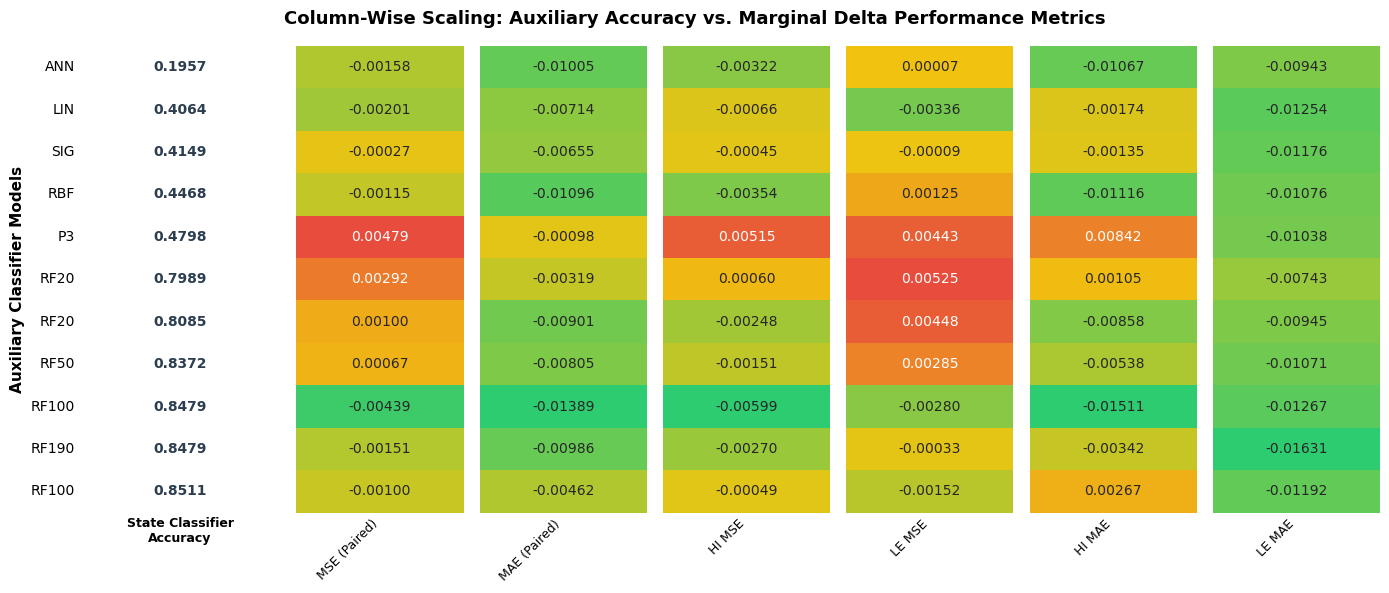

In [5]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns


# --- 1. Prepare Data with Short Names ---
name_mapping = {
    "ANN": "ANN",
    "linear": "LIN",
    "sigmoid": "SIG",
    "rbf": "RBF",
    "poly": "P3",
    "20": "RF20",
    "50": "RF50",
    "100": "RF100",
    "190": "RF190",
}
metric_mapping = {
    "mse_losses": "MSE (Paired)",
    "mae_losses": "MAE (Paired)",
    "mse_health_index": "HI MSE",
    "mse_life_expectation": "LE MSE",
    "mae_health_index": "HI MAE",
    "mae_life_expectation": "LE MAE",
}


def clean_labels(idx_string):
    for key, short_name in name_mapping.items():
        if key in idx_string:
            return short_name
    return idx_string


# Create complete working dataframe combining accuracy and mapped delta losses
df_plot = df_diff_sorted.copy()
df_plot.index = df_plot.index.map(clean_labels)
df_plot = df_plot.rename(columns=metric_mapping)

# Reorder: Classification Accuracy goes first from the left, followed by losses
columns_ordered = ["state_classifier_accuracy"] + list(metric_mapping.values())

# --- 2. Custom Color Scale Builder ---
# Green for negative delta (improvement), Yellow for 0 (baseline), Red for positive delta (degradation)
colors = ["#2ecc71", "#f1c40f", "#e74c3c"]
cmap_losses = mcolors.LinearSegmentedColormap.from_list("GreenYellowRed", colors)

cmap_white = mcolors.ListedColormap(["#ffffff"])
# --- 3. Grid Visualization Subplots ---
# Set up a grid of 7 independent columns sharing the same Y-axis rows
fig, axes = plt.subplots(
    1,
    7,
    figsize=(14, 6),
    sharey=True,
    gridspec_kw={"width_ratios": [1.2, 1, 1, 1, 1, 1, 1]},
)

for i, col in enumerate(columns_ordered):
    ax = axes[i]
    col_data = df_plot[[col]]

    if col == "state_classifier_accuracy":
        # Column 1: Classification Accuracy with a flat white background palette
        sns.heatmap(
            col_data,
            annot=True,
            fmt=".4f",
            cmap=cmap_white,
            cbar=False,
            ax=ax,
            annot_kws={"weight": "bold", "color": "#2c3e50"},
        )
        ax.set_xticklabels(
            ["State Classifier\nAccuracy"], rotation=0, fontsize=9, weight="bold"
        )
    else:
        # Columns 2-7: Localized Loss Delta Scales centered at 0
        vabs = max(abs(col_data.min().values[0]), abs(col_data.max().values[0]))
        sns.heatmap(
            col_data,
            annot=True,
            fmt=".5f",
            cmap=cmap_losses,
            vmin=-vabs,
            vmax=vabs,
            center=0,
            cbar=False,
            ax=ax,
        )
        ax.set_xticklabels([col], rotation=45, ha="right", fontsize=9)

    ax.set_ylabel("")
    ax.tick_params(axis="both", which="both", length=0)

axes[0].set_ylabel("Auxiliary Classifier Models", fontsize=11, weight="bold")
plt.suptitle(
    "Column-Wise Scaling: Auxiliary Accuracy vs. Marginal Delta Performance Metrics",
    fontsize=13,
    weight="bold",
    y=0.98,
)
plt.tight_layout()
plt.show()

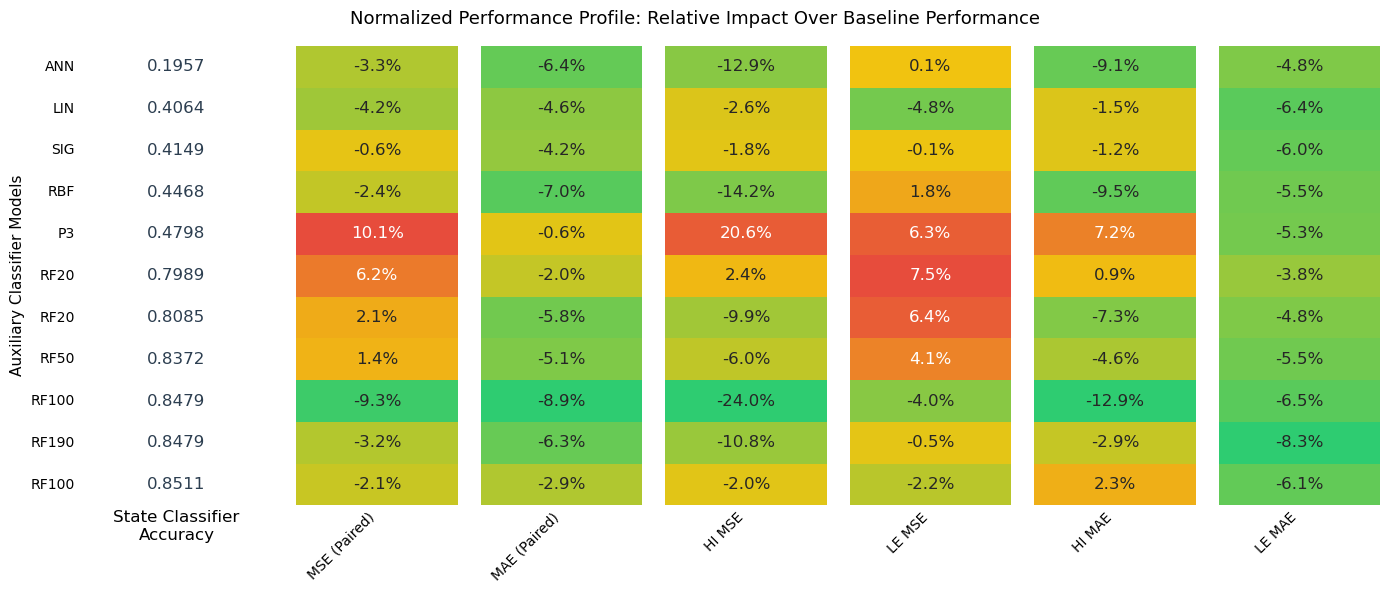

In [6]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# --- 1. Compute Normalized Relative Performance ---
# Assuming 'df' is your raw, original DataFrame containing the 'original_None_None' row

# Extract the baseline row values for the loss metrics
loss_cols = mean_df.columns.drop("state_classifier_accuracy")
baseline = mean_df.loc["original_None_None", loss_cols]

# Create a copy and calculate: (Model - Baseline) / Baseline
df_relative = mean_df.copy()
df_relative[loss_cols] = mean_df[loss_cols].sub(baseline).div(baseline)

# Drop baseline row and sort by classifier accuracy as before
df_relative = df_relative.drop("original_None_None")
df_relative_sorted = df_relative.sort_values(
    by="state_classifier_accuracy", ascending=True
)

# --- 2. Prepare Data with Short Names ---
name_mapping = {
    "ANN": "ANN",
    "linear": "LIN",
    "sigmoid": "SIG",
    "rbf": "RBF",
    "poly": "P3",
    "20": "RF20",
    "50": "RF50",
    "100": "RF100",
    "190": "RF190",
}
metric_mapping = {
    "mse_losses": "MSE (Paired)",
    "mae_losses": "MAE (Paired)",
    "mse_health_index": "HI MSE",
    "mse_life_expectation": "LE MSE",
    "mae_health_index": "HI MAE",
    "mae_life_expectation": "LE MAE",
}


def clean_labels(idx_string):
    for key, short_name in name_mapping.items():
        if key in idx_string:
            return short_name
    return idx_string


df_plot = df_relative_sorted.copy()
df_plot.index = df_plot.index.map(clean_labels)
df_plot = df_plot.rename(columns=metric_mapping)

columns_ordered = ["state_classifier_accuracy"] + list(metric_mapping.values())

# --- 3. Custom Color Scale Builders ---
# Green for negative delta (improvement), Yellow for 0 (no change), Red for positive delta (degradation)
colors = ["#2ecc71", "#f1c40f", "#e74c3c"]
cmap_losses = mcolors.LinearSegmentedColormap.from_list("GreenYellowRed", colors)
cmap_white = mcolors.ListedColormap(["#ffffff"])

# --- 4. Grid Visualization Subplots ---
fig, axes = plt.subplots(
    1,
    7,
    figsize=(14, 6),
    sharey=True,
    gridspec_kw={"width_ratios": [1.2, 1, 1, 1, 1, 1, 1]},
)

for i, col in enumerate(columns_ordered):
    ax = axes[i]
    col_data = df_plot[[col]]

    if col == "state_classifier_accuracy":
        # Column 1: Raw Accuracy values stay as absolute numbers
        sns.heatmap(
            col_data,
            annot=True,
            fmt=".4f",
            cmap=cmap_white,
            cbar=False,
            ax=ax,
            annot_kws={"color": "#2c3e50", "size": 12},
        )
        ax.set_xticklabels(
            ["State Classifier\nAccuracy"], rotation=0, fontsize=12,
            # weight="bold"
        )
    else:
        # Columns 2-7: Percentage format (".1%") centered around 0 relative change
        vabs = max(abs(col_data.min().values[0]), abs(col_data.max().values[0]))

        # Guard against zero-variance columns to prevent plotting errors
        if vabs == 0:
            vabs = 1.0

        sns.heatmap(
            col_data,
            annot=True,
            fmt=".1%",
            cmap=cmap_losses,
            vmin=-vabs,
            vmax=vabs,
            center=0,
            cbar=False,
            ax=ax,
            annot_kws={"size": 12},
        )
        ax.set_xticklabels([col], rotation=45, ha="right", fontsize=10)
    ax.set_ylabel("")
    ax.tick_params(axis="both", which="both", length=0)

axes[0].set_ylabel("Auxiliary Classifier Models", fontsize=11, 
                #    weight="bold"
                   )
plt.suptitle(
    "Normalized Performance Profile: Relative Impact Over Baseline Performance",
    fontsize=13,
    # weight="bold",
    y=0.98,
)
plt.tight_layout()
plt.show()


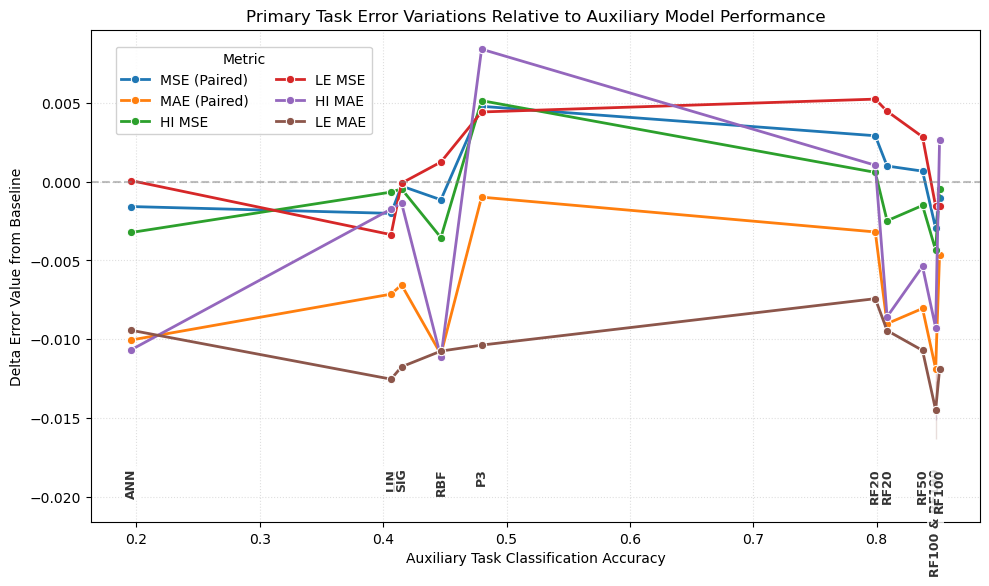

In [7]:
name_mapping = {
    "ANN": "ANN",
    "linear": "LIN",
    "sigmoid": "SIG",
    "rbf": "RBF",
    "poly": "P3",
    "20": "RF20",
    "50": "RF50",
    "100": "RF100",
    "190": "RF190",
}


def clean_labels(idx_string):
    for key, short_name in name_mapping.items():
        if key in idx_string:
            return short_name
    return idx_string


# Apply index renaming
df_diff_sorted.index = df_diff_sorted.index.map(clean_labels)

df_diff_sorted["Legend_Group"] = (
    df_diff_sorted.index
    + " ("
    + (df_diff_sorted["state_classifier_accuracy"] * 100).round(1).astype(str)
    + "%)"
)

metric_mapping = {
    "mse_losses": "MSE (Paired)",
    "mae_losses": "MAE (Paired)",
    "mse_health_index": "HI MSE",
    "mse_life_expectation": "LE MSE",
    "mae_health_index": "HI MAE",
    "mae_life_expectation": "LE MAE",
}

metrics = list(metric_mapping.keys())

# 2. Melt data using accuracy as the continuous X variable
df_melted_trend = df_diff_sorted.reset_index().melt(
    id_vars=["index", "state_classifier_accuracy"],
    value_vars=metrics,
    var_name="Metric",
    value_name="Marginal Difference",
)

# --- FIX: Map the long metric strings to your short versions ---
df_melted_trend["Metric"] = df_melted_trend["Metric"].map(metric_mapping)

# 3. Plot (Seaborn will now automatically use the mapped short names for the legend lines)
plt.figure(figsize=(10, 6))
ax = sns.lineplot(
    data=df_melted_trend,
    x="state_classifier_accuracy",
    y="Marginal Difference",
    hue="Metric",
    marker="o",
    linewidth=2,
)

# Intercept line showing baseline performance boundary
plt.axhline(0, color="gray", linestyle="--", alpha=0.5)

# Adjust Legend position to Top Left with horizontal columns
plt.legend(
    title="Metric",
    loc="upper left",
    bbox_to_anchor=(0.02, 0.98),
    ncol=2,
    framealpha=0.9,
)

# Create an explicit bottom margin track for labels
ymin, ymax = ax.get_ylim()
padding = (ymax - ymin) * 0.15
ax.set_ylim(ymin - padding, ymax)

# Re-read the adjusted lower limit
ymin_new, _ = ax.get_ylim()
text_y_position = ymin_new + padding * 0.85

# Group models by accuracy
grouped_labels = df_diff_sorted.groupby("state_classifier_accuracy").apply(
    lambda x: " & ".join(x.index)
)

for acc, model_names in grouped_labels.items():
    plt.text(
        x=acc,
        y=text_y_position,
        s=model_names,
        rotation=90,
        va="top",
        ha="center",
        fontsize=9,
        fontweight="bold",
        alpha=0.8,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=1.5),
    )

plt.title(
    "Primary Task Error Variations Relative to Auxiliary Model Performance", fontsize=12
)
plt.xlabel("Auxiliary Task Classification Accuracy", fontsize=10)
plt.ylabel("Delta Error Value from Baseline", fontsize=10)
plt.grid(True, linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()